# Isaac Balam Rodriguez Arellano
# Collen Foster Ellis

# Lab Work 11 (Students version): communities using label propagation

We can use the following libraries.

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import math
import sys
import random
import time
import numpy as np
import scipy.sparse as sp 
from collections import Counter, defaultdict
print(sys.version)

3.13.3 (tags/v3.13.3:6280bb5, Apr  8 2025, 14:47:33) [MSC v.1943 64 bit (AMD64)]


### Preliminary question

Load in memory as a dictionary of lists the undirected graph called <code>synthetic_network.txt</code> on Moodle. As its name indicates, it simulates a complex network (for instance contact between individuals). 

In [2]:
def load_graph(filename):
    graph = {}

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue

            u, v = line.split()
            u = int(u)
            v = int(v)

            if u not in graph:
                graph[u] = []
            if v not in graph:
                graph[v] = []

            graph[u].append(v)
            graph[v].append(u)

    return graph

graph = load_graph("synthetic_network.txt")


You can execute the blocks below to have an idea of the structure of your graph, by replacing the variable <code>X</code> by the name of the variable where you stored the network <code>synthetic_network.txt</code>.

In [3]:
import networkx as nx

def transform_to_nx (graph):
    G = nx.Graph() 
    for node in graph:
        G.add_node(node)
        for neigh in graph[node]:
            G.add_edge(node,neigh)
    return G

def network_visualization(graph , zoom=30, layout=None, community_assignment={}):
    G = transform_to_nx(graph)
    deg_0_nodes = [node for node,degree in dict(G.degree()).items() if degree == 0]
    G.remove_nodes_from(deg_0_nodes)
    if layout==None:
        layout = nx.spring_layout(G) 
    plt.figure(figsize=(zoom,zoom))
    if len(community_assignment) == 0:
        nx.draw(G, pos=layout)
    else:
        nx.draw(G, pos=layout, node_color=list(community_assignment.values()))
    return layout


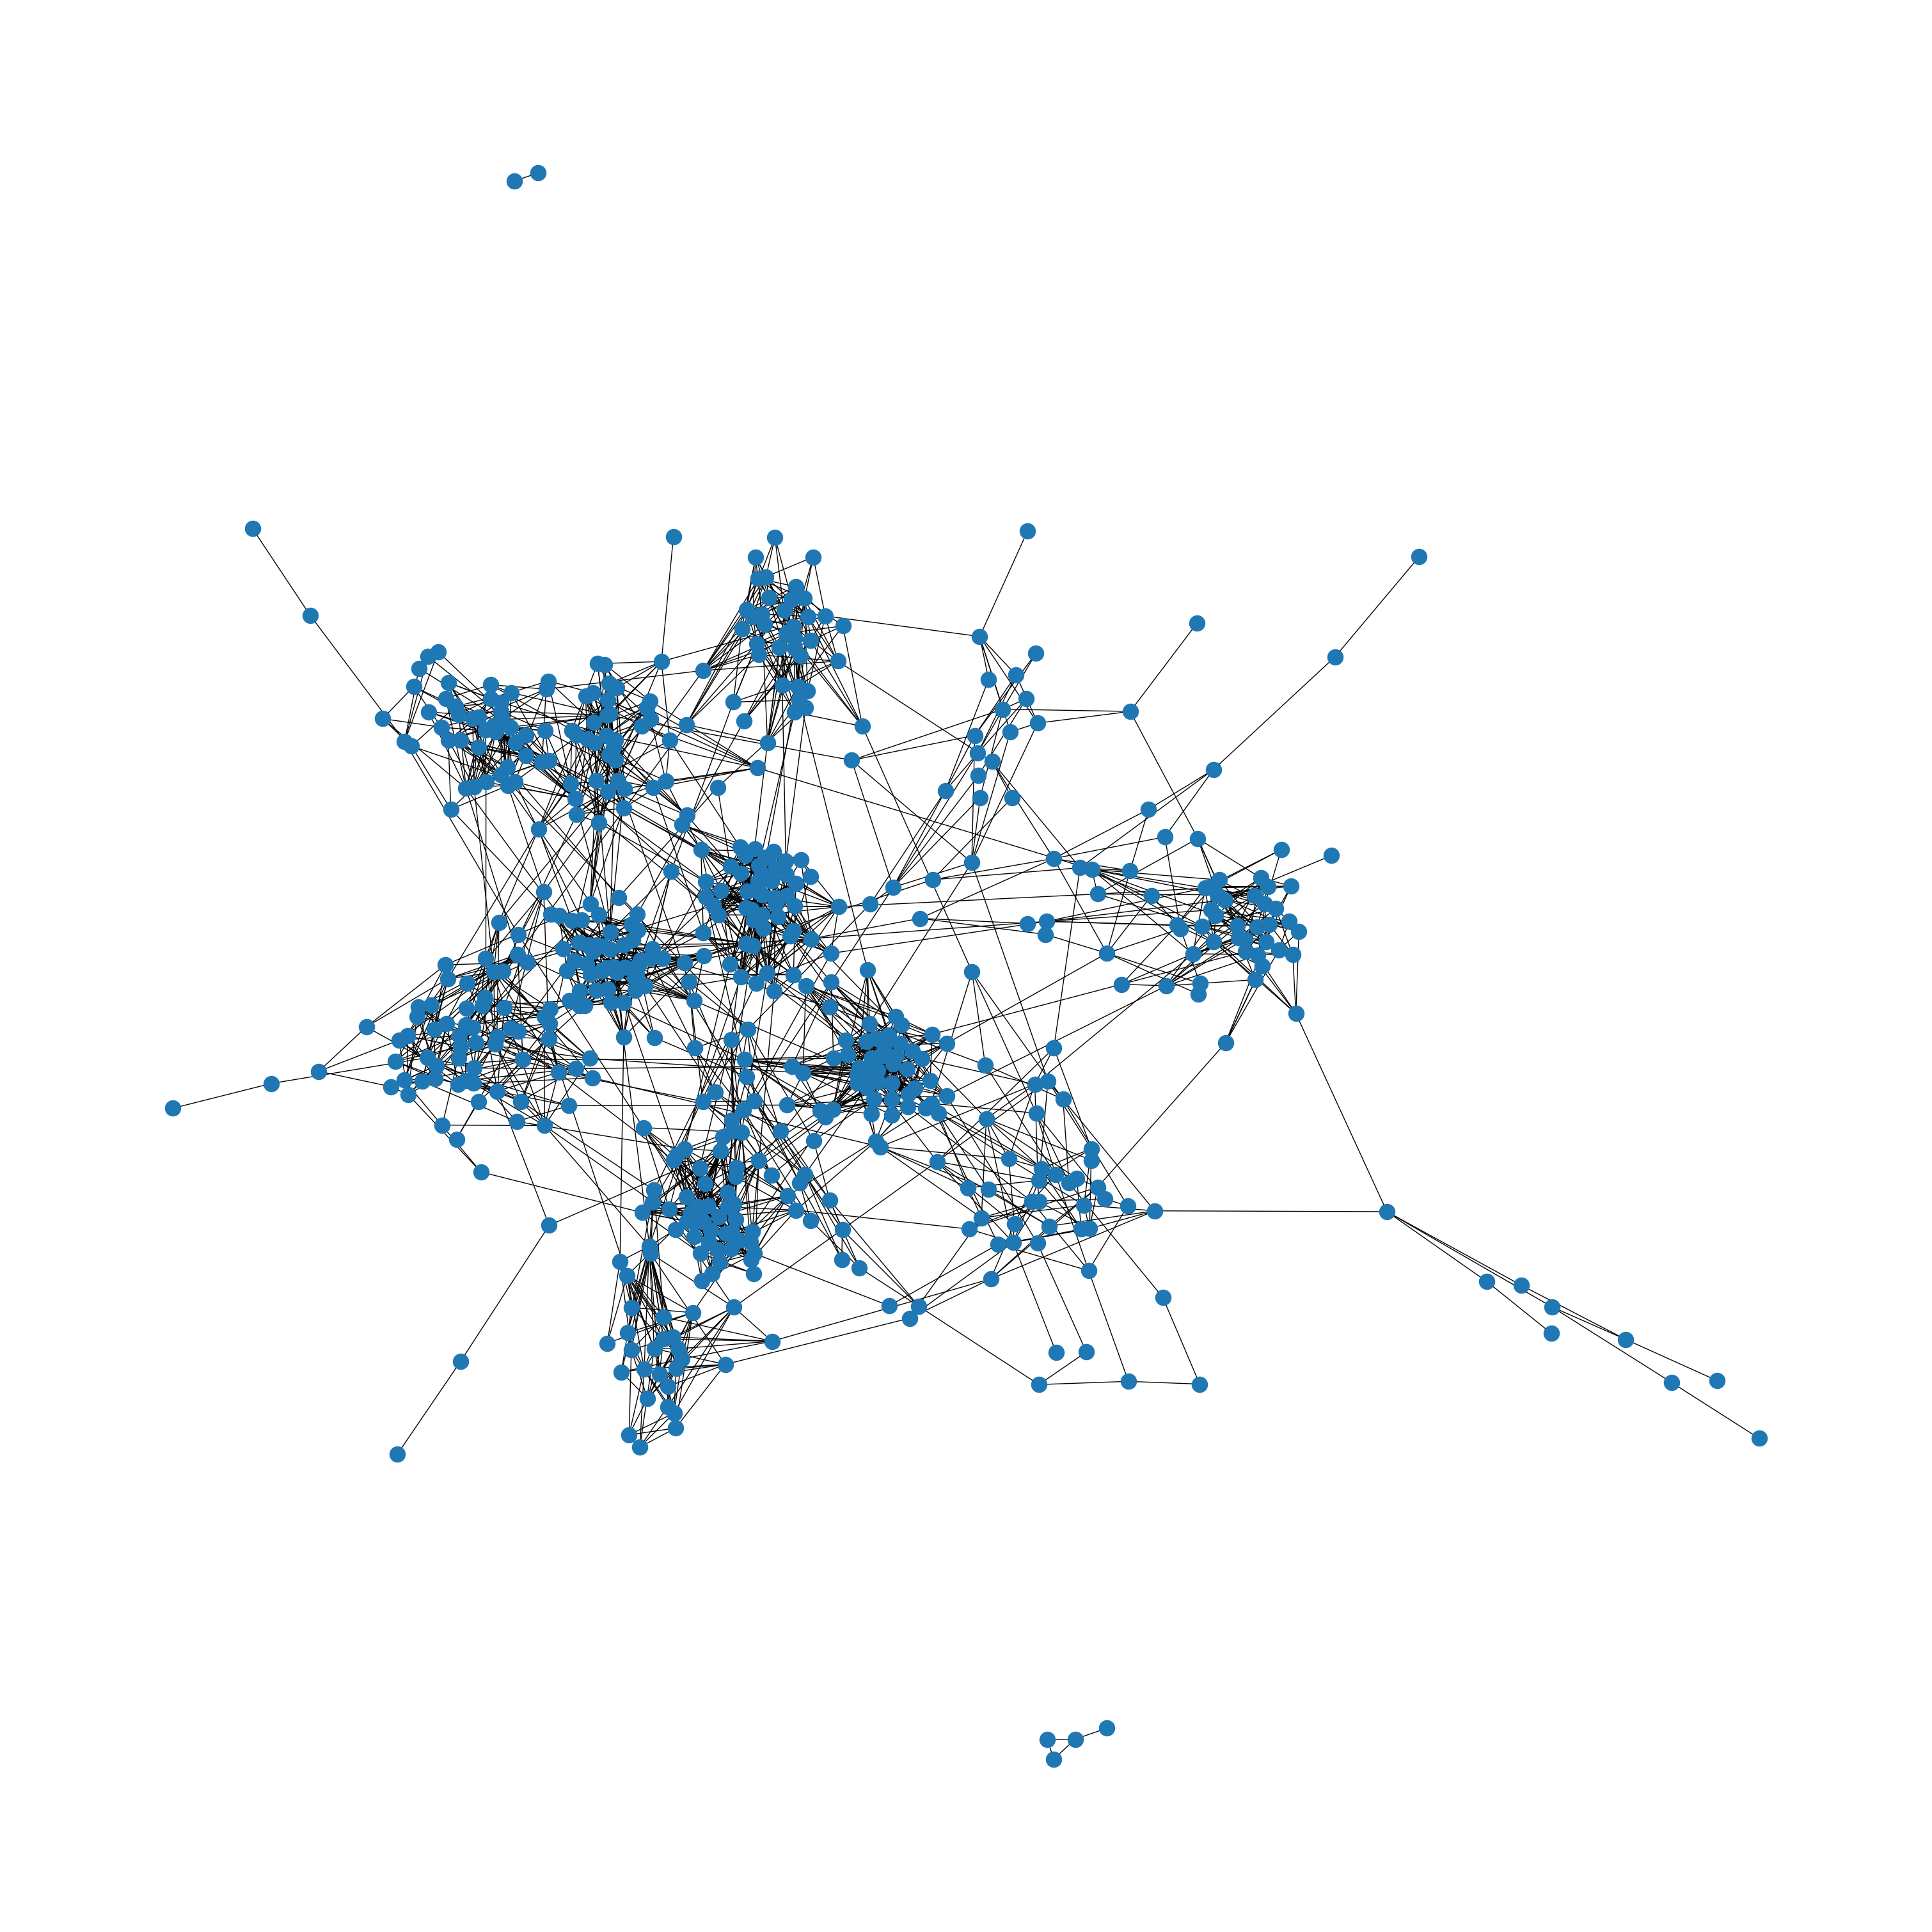

In [4]:
layout = network_visualization(graph)

### Question 1

We remind here the Label Propagation algorithm described in the course:

* 1. Initialization: give a unique label to each node in the network

* 2. For each node in the network taken in random order, set its label to the majority label among its neighbours (in case of ties, decide randomly)

* 3. Go back to step 2 and iterate until all nodes have a label corresponding to the highest frequency in their neighborhood.

Implement this algorithm, the output is a dictionary where keys are nodes and the associated values are the community number.

Apply it to the dataset <code>synthetic_network.txt</code>.

In [5]:
def label_propagation(graph, max_iter=1000, seed=0):
    rng = random.Random(seed)

    labels = {node: node for node in graph}

    nodes = list(graph.keys())

    for _ in range(max_iter):
        changed = False
        rng.shuffle(nodes)  

        for node in nodes:
            neighs = graph[node]
            if not neighs:  
                continue

            neigh_labels = [labels[n] for n in neighs]
            counts = Counter(neigh_labels)
            max_freq = max(counts.values())

            candidates = [lab for lab, c in counts.items() if c == max_freq]
            new_label = rng.choice(candidates)

            if new_label != labels[node]:
                labels[node] = new_label
                changed = True

        if not changed:
            break

    unique_labels = {}
    comm_id = 0
    communities = {}
    for node, lab in labels.items():
        if lab not in unique_labels:
            unique_labels[lab] = comm_id
            comm_id += 1
        communities[node] = unique_labels[lab]

    return communities

graph = load_graph("synthetic_network.txt")
communities = label_propagation(graph)
print(communities)
print("\n")
def communities_to_sets(node_to_comm):
    comms = defaultdict(list)
    for node, comm in node_to_comm.items():
        comms[comm].append(node)
    return dict(comms)

communities = communities_to_sets(communities)

for comm, nodes in sorted(communities.items()):
    print(f"Community {comm} ({len(nodes)} nodes):")
    print(sorted(nodes))
    print()


{0: 0, 26: 0, 36: 0, 41: 0, 47: 0, 1: 0, 5: 0, 9: 0, 23: 0, 24: 0, 28: 0, 2: 0, 3: 0, 10: 0, 15: 0, 16: 0, 18: 0, 30: 0, 31: 0, 33: 0, 34: 0, 38: 0, 40: 0, 45: 0, 48: 0, 179: 1, 402: 2, 4: 0, 12: 0, 19: 0, 29: 0, 32: 0, 46: 0, 331: 3, 14: 0, 17: 0, 43: 0, 44: 0, 49: 0, 8: 0, 13: 0, 20: 0, 37: 0, 6: 0, 11: 0, 35: 0, 463: 4, 7: 0, 22: 0, 25: 0, 21: 0, 39: 0, 42: 0, 50: 5, 150: 1, 492: 6, 156: 1, 27: 0, 384: 2, 503: 7, 184: 1, 476: 4, 153: 1, 431: 8, 122: 9, 225: 10, 105: 9, 191: 1, 286: 11, 514: 12, 443: 8, 444: 8, 296: 11, 549: 12, 266: 13, 101: 9, 540: 12, 527: 14, 51: 5, 67: 5, 71: 5, 75: 5, 77: 5, 79: 5, 86: 5, 99: 5, 301: 11, 53: 5, 63: 5, 65: 5, 68: 5, 74: 5, 84: 5, 52: 5, 60: 5, 61: 5, 76: 5, 80: 5, 89: 5, 92: 5, 55: 5, 56: 5, 62: 5, 73: 5, 78: 5, 87: 5, 94: 5, 54: 5, 59: 5, 69: 5, 82: 5, 466: 4, 57: 5, 81: 5, 88: 5, 90: 5, 91: 5, 96: 5, 97: 5, 58: 5, 505: 7, 83: 5, 433: 8, 72: 5, 93: 5, 66: 5, 95: 5, 98: 5, 64: 5, 70: 5, 85: 5, 554: 12, 255: 13, 513: 7, 264: 13, 447: 8, 339: 3, 2

### Question 2

Modify the previous code to store the number of iterations. Then compute on 100 runs of the algorithm the average number of iterations. 

In [6]:
def label_propagation(graph, max_iter=1000, seed=None):
    rng = random.Random(seed)

    labels = {node: node for node in graph}
    nodes = list(graph.keys())

    for it in range(1, max_iter + 1):
        changed = False
        rng.shuffle(nodes)

        for node in nodes:
            neighs = graph[node]
            if not neighs:
                continue

            neigh_labels = [labels[n] for n in neighs]
            counts = Counter(neigh_labels)
            max_freq = max(counts.values())

            candidates = [lab for lab, c in counts.items() if c == max_freq]
            new_label = rng.choice(candidates)

            if new_label != labels[node]:
                labels[node] = new_label
                changed = True

        if not changed:
            break

    label_map = {}
    comm_id = 0
    communities = {}
    for node, lab in labels.items():
        if lab not in label_map:
            label_map[lab] = comm_id
            comm_id += 1
        communities[node] = label_map[lab]

    return communities, it


def average_iterations(graph, runs=100):
    iterations = []

    for i in range(runs):
        _, it = label_propagation(graph, seed=i)
        iterations.append(it)

    avg_iter = sum(iterations) / runs
    return avg_iter, iterations

graph = load_graph("synthetic_network.txt")

avg_iter, all_iters = average_iterations(graph, runs=100)

print("Average number of iterations:", avg_iter)
print("Min iterations:", min(all_iters))
print("Max iterations:", max(all_iters))



Average number of iterations: 214.84
Min iterations: 17
Max iterations: 1000


You can execute the block below to have a visual idea of the quality of the community detection, by replacing the variable <code>X</code> by the name of the variable where you stored the network <code>synthetic_network.txt</code> and the variable <code>Y</code> by a dictionary where keys are nodes and the associated values are the community number.

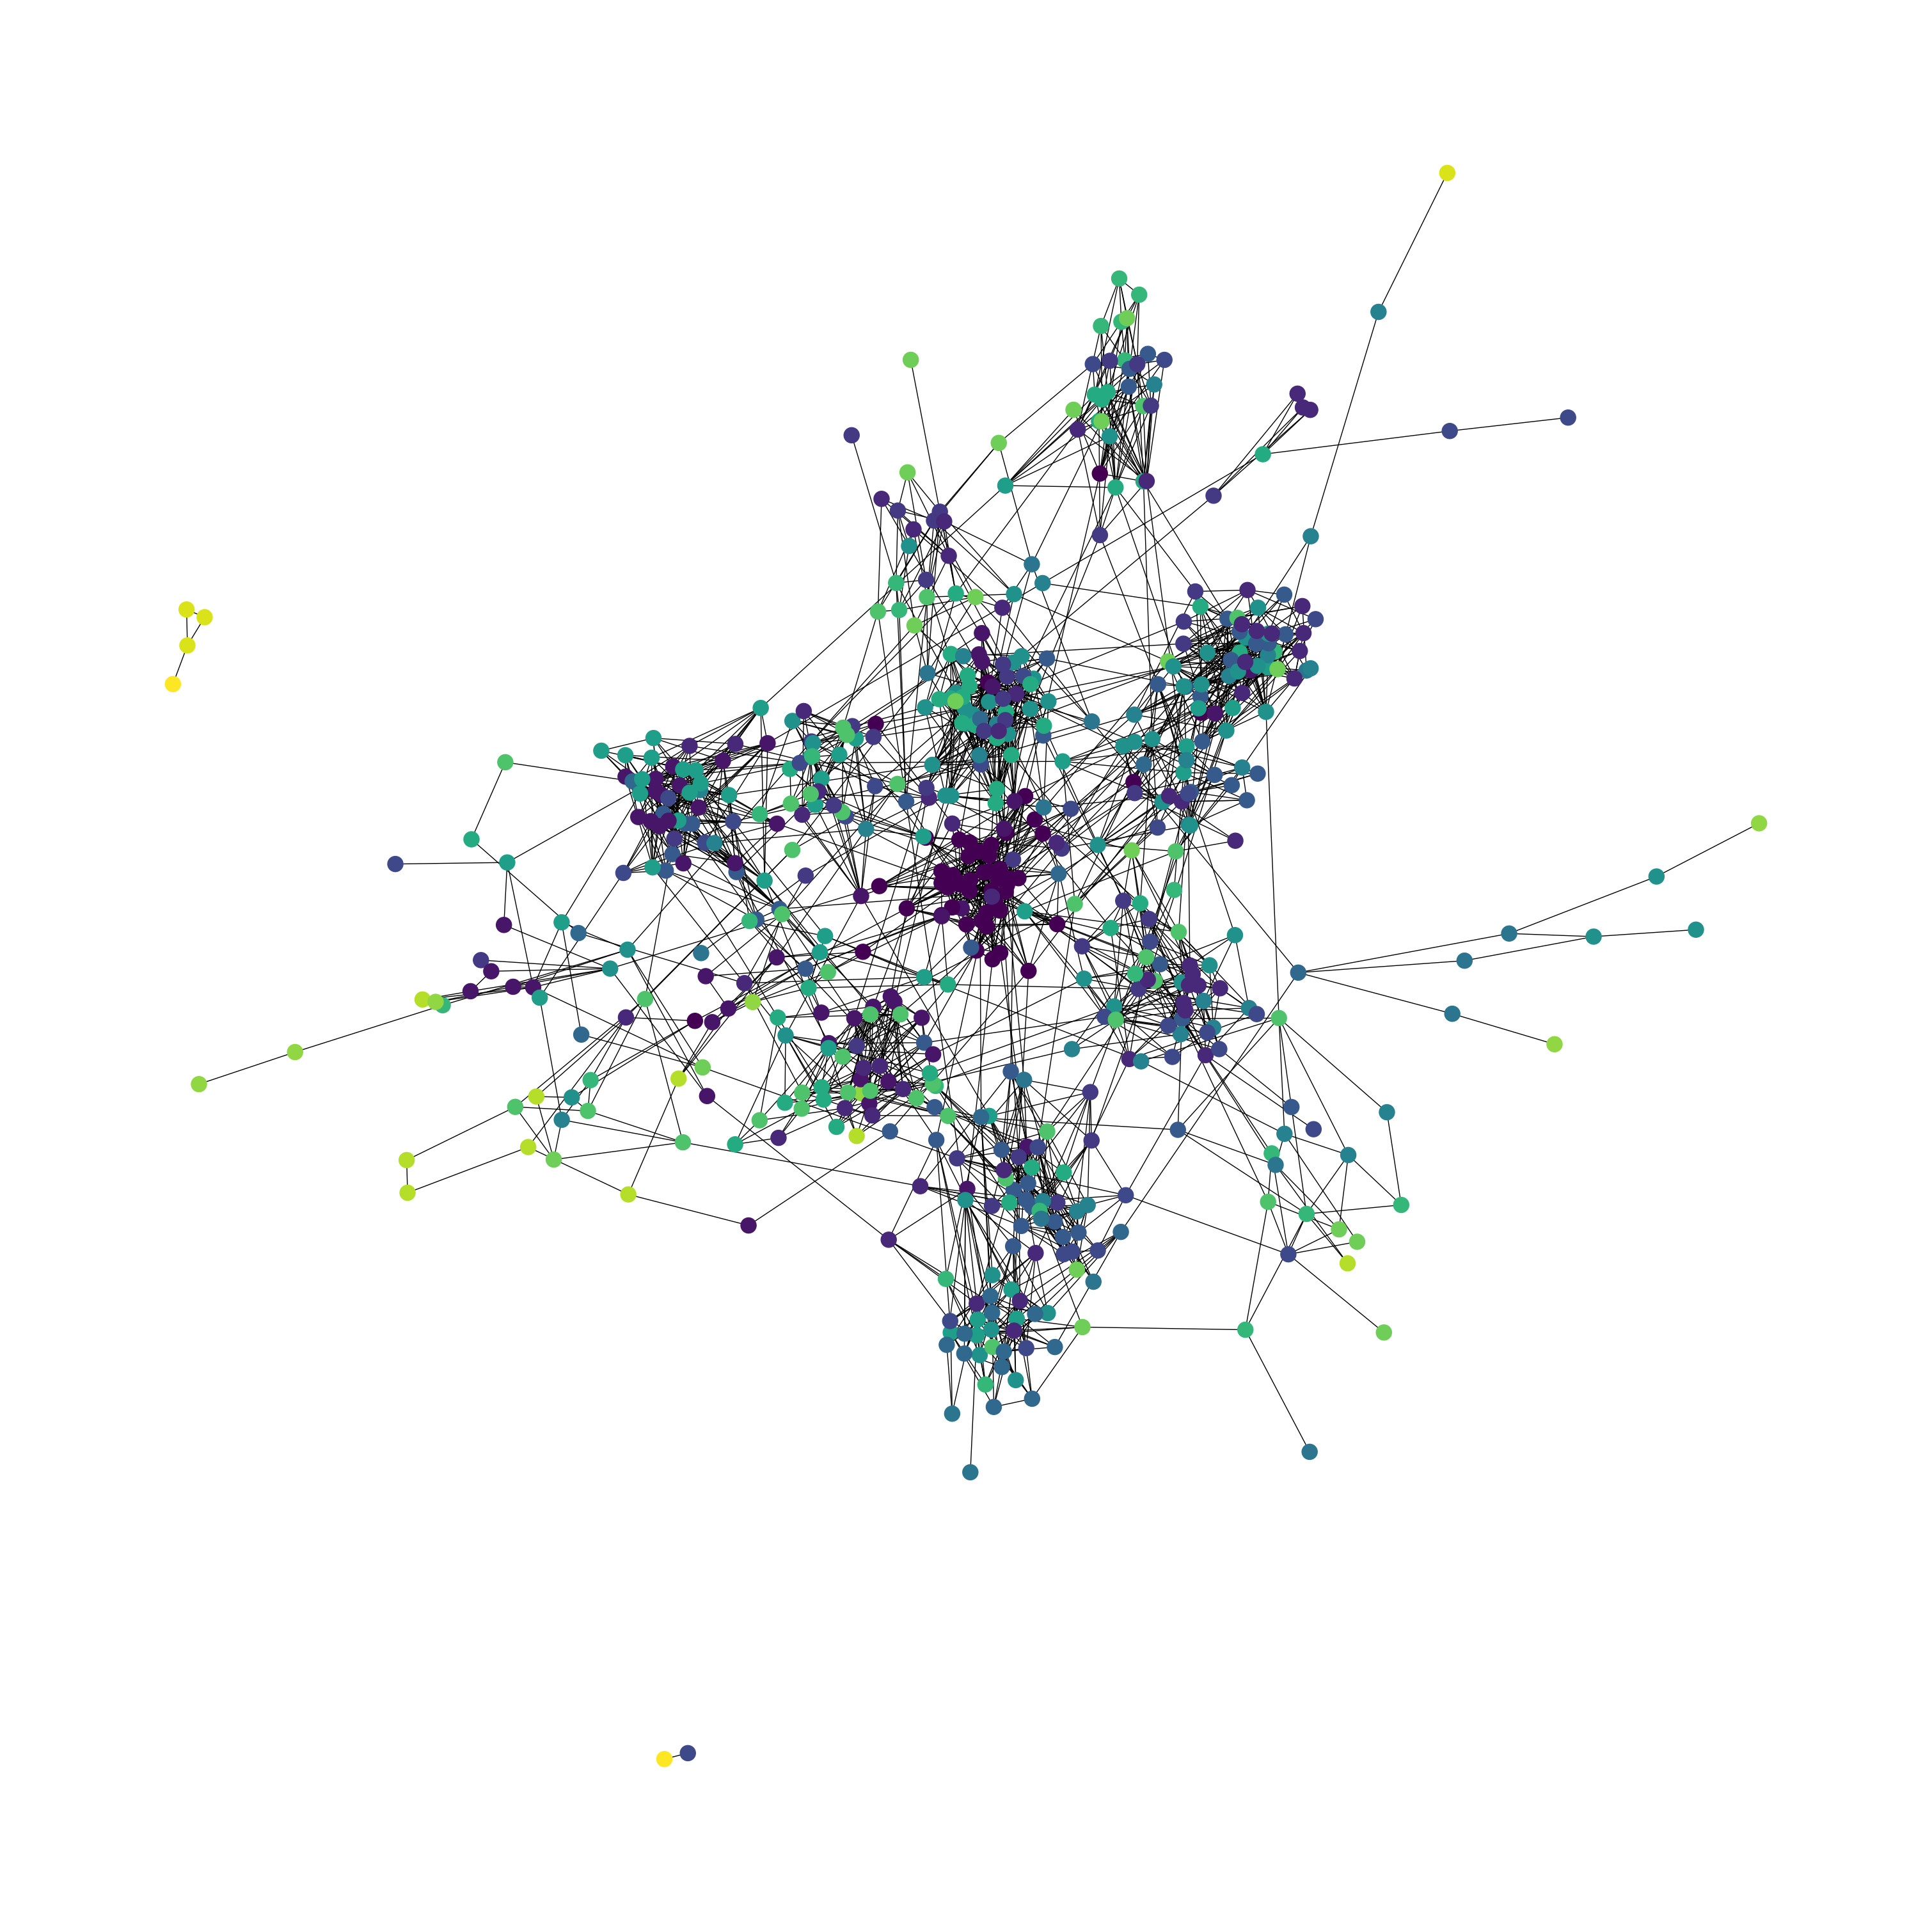

In [7]:
communities, it = label_propagation(graph, seed=0)

def reindexation (com_tab):
    com_tab_reind = {}
    index = {}
    com_reind = 0
    for node in com_tab:
        if com_tab[node] not in index:
            index[com_tab[node]] = com_reind
            com_reind += 1
        com_tab_reind[node] = index[com_tab[node]]
    return com_tab_reind

communities, it = label_propagation(graph, seed=0)
_ = network_visualization(graph, community_assignment=reindexation(communities))
plt.show()

### Question 3

Compute and plot the distribution of the community sizes that you obtained. What can you say about this distribution?

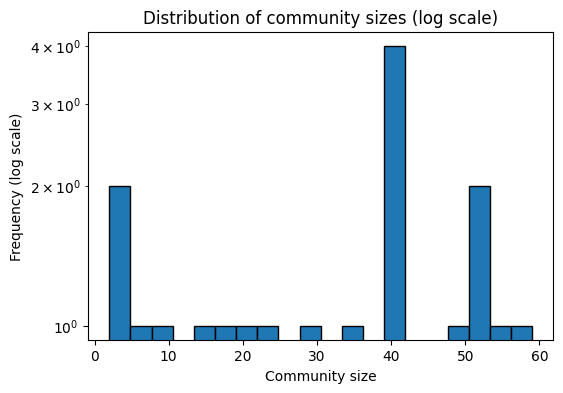

Number of communities: 19
Largest community size: 59
Smallest community size: 2


In [8]:
# communities: {node: community_id}
community_sizes = Counter(communities.values())
sizes = list(community_sizes.values())

plt.figure(figsize=(6,4))
plt.hist(sizes, bins=20, edgecolor="black")
plt.yscale("log")
plt.xlabel("Community size")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of community sizes (log scale)")
plt.show()

print("Number of communities:", len(community_sizes))
print("Largest community size:", max(sizes))
print("Smallest community size:", min(sizes))

#The distribution is highly skewed: many communities are small (high frequency on the left), and only a few are large.  
#On a log scale this kind of “heavy-tail” pattern is common in complex networks: it suggests heterogeneous structure rather than equally-sized groups.

### Question 4

We remind you of the definition of the modularity score:

$$ Q = \frac{1}{2m} \sum_{i = 1}^{k}  \sum_{u \in S_i} d(u)_{in} -  \frac{vol(S_i)^2}{ 2m } $$

where 

* $d(u)_{in}$ is the part if the degree of node $u$ that goes to nodes in $ S_i $

* $vol(S_i) = \sum_{u \in S_i} d(u)$ is the sum of the degree of a node inside a community


a) Generate Erdös-Rényi graphs with the following number of $n$ and $m$:

* n=1000 , m=2000

* n=1000 , m=5000

b) Compute the modularity of the partition that produces the LP algorithm for the Erdös-Rényi graphs generated. What do you observe? (you can visualize the communities using the function in Q2 to understand what is going on)

In [9]:
def er_graph(n, m, seed=0):
    rng = random.Random(seed)
    graph = {i: set() for i in range(n)}
    edges = set()

    while len(edges) < m:
        u = rng.randrange(n)
        v = rng.randrange(n)
        if u == v:
            continue
        if u > v:
            u, v = v, u
        if (u, v) in edges:
            continue

        edges.add((u, v))
        graph[u].add(v)
        graph[v].add(u)

    # convert to lists for consistency
    return {u: list(neighs) for u, neighs in graph.items()}

def modularity(graph, communities):
    deg = {u: len(graph[u]) for u in graph}
    two_m = sum(deg.values())  # = 2m

    if two_m == 0:
        return 0.0

    comm_nodes = defaultdict(list)
    for u, cid in communities.items():
        comm_nodes[cid].append(u)

    Q = 0.0
    for nodes in comm_nodes.values():
        node_set = set(nodes)
        vol = 0
        d_in = 0

        for u in nodes:
            vol += deg[u]
            d_in += sum(1 for v in graph[u] if v in node_set)

        Q += d_in - (vol * vol) / two_m

    return Q / two_m


# Generate graphs
G1 = er_graph(n=1000, m=2000, seed=0)
G2 = er_graph(n=1000, m=5000, seed=0)

# Run label propagation
communities1, it1 = label_propagation(G1, seed=0)
communities2, it2 = label_propagation(G2, seed=0)

# Compute modularity
Q1 = modularity(G1, communities1)
Q2 = modularity(G2, communities2)

print("ER n=1000 m=2000")
print("  modularity:", Q1)
print("  #communities:", len(set(communities1.values())))
print("  iterations:", it1)

print("ER n=1000 m=5000")
print("  modularity:", Q2)
print("  #communities:", len(set(communities2.values())))
print("  iterations:", it2)



ER n=1000 m=2000
  modularity: 0.003990624999999978
  #communities: 28
  iterations: 48
ER n=1000 m=5000
  modularity: 0.0
  #communities: 1
  iterations: 6


### Question 5

Compute on 100 runs the modularity of the partition that you obtain with LP on <code>synthetic_network.txt</code>.

Plot the histogram of the modularites obtained over these 100 runs of the algorithm and comment on the range of values obtained (I advise you to use the function <code>hist</code> in matplotlib).

Min modularity: 0.8259372760110154
Max modularity: 0.8540538862481765
Average modularity: 0.8509314670335368


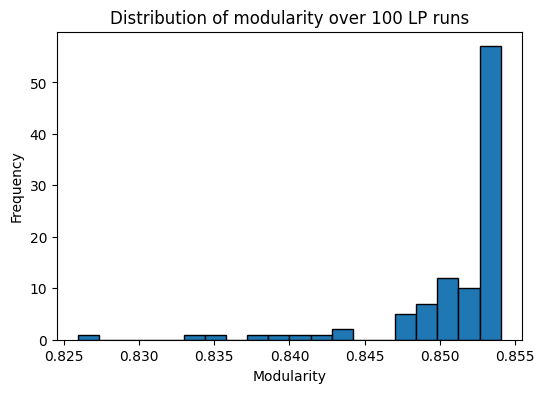

In [10]:
modularities = []
iterations = []

for seed in range(100):
    communities, it = label_propagation(graph, seed=seed)
    Q = modularity(graph, communities)
    modularities.append(Q)
    iterations.append(it)

print("Min modularity:", min(modularities))
print("Max modularity:", max(modularities))
print("Average modularity:", sum(modularities) / len(modularities))

plt.figure(figsize=(6,4))
plt.hist(modularities, bins=20, edgecolor="black")
plt.xlabel("Modularity")
plt.ylabel("Frequency")
plt.title("Distribution of modularity over 100 LP runs")
plt.show()



### Question 6

Run the following block to define a function that computes the Adjusted Rand Index (ARI) defined in the course using the machine learning package scikit-learn (you need to install it on your machine if it is not).

Note that the format of the input requested are dictionaries where keys are nodes and the associated values are the community number.

In [11]:
from sklearn.metrics import adjusted_rand_score

def ari_score(comm_assignment_1, community_assignment_2):
    ca1 = list(comm_assignment_1.values())
    ca2 = list(community_assignment_2.values())
    return adjusted_rand_score(ca1, ca2)

Select two realizations of LP on <code>synthetic_network.txt</code> compute the ARI value and comment briefly.   

In [12]:
communities_1, it1 = label_propagation(graph, seed=0)
communities_2, it2 = label_propagation(graph, seed=1)

print("Iterations run 1:", it1)
print("Iterations run 2:", it2)

ari = ari_score(communities_1, communities_2)
print("ARI:", ari)

#The ARI between two different runs of the Label Propagation algorithm on the synthetic network is very high (ARI ≈ 0.93)
#indicating that the detected community structure is highly stable despite the stochastic nature of the algorithm.

Iterations run 1: 154
Iterations run 2: 51
ARI: 0.9344429005054227


### Question 7 (bonus question)

Run the LP algorithm on two undirected graphs available on Moodle that we have already seen : <code>IP-inet-undir.txt</code> and <code>AS-Caida-undir.txt</code>. 

For both graphs
- plot the distribution of the community sizes on one realization of the algorithm, what kind of shape has this distribution?
- compute the modularity obtained on 100 realizations of LP and comment on the shape of the distrbution (narrow or large? bell-shaped or not?)

**Warning:** be careful that these graphs are larger than <code>synthetic_network.txt</code> so if your code is not efficient, 100 realizations might be long (especially for <code>AS-Caida-undir.txt</code> network).